In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
from workout_intel_core.dataset import load_raw_data

data = load_raw_data()

data.head()

,Unnamed: 0,Exercise_Name,muscle_gp,Equipment,Rating
0,0,Rickshaw Carry,Forearms,Other,9.6
1,1,Single-Leg Press,Quadriceps,Machine,9.6
2,2,Landmine twist,Abdominals,Other,9.5
3,3,Weighted pull-up,Lats,Other,9.5
4,4,T-Bar Row with Handle,Middle Back,Other,9.5


In [38]:
data.shape

(469, 5)

<Axes: xlabel='muscle_gp', ylabel='Rating'>

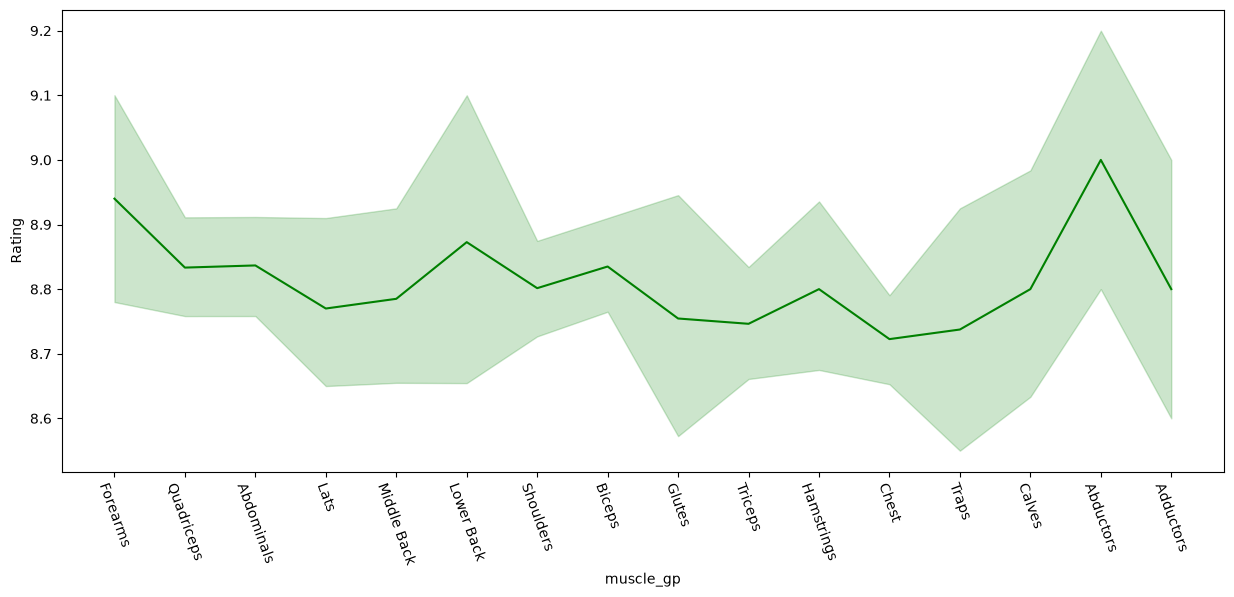

In [39]:
# Variations in the ratings for all muscle groups.
plt.figure(figsize=(15, 6))
plt.xticks(rotation=290)
sns.lineplot(data, x=data.muscle_gp, y=data.Rating, color='green')

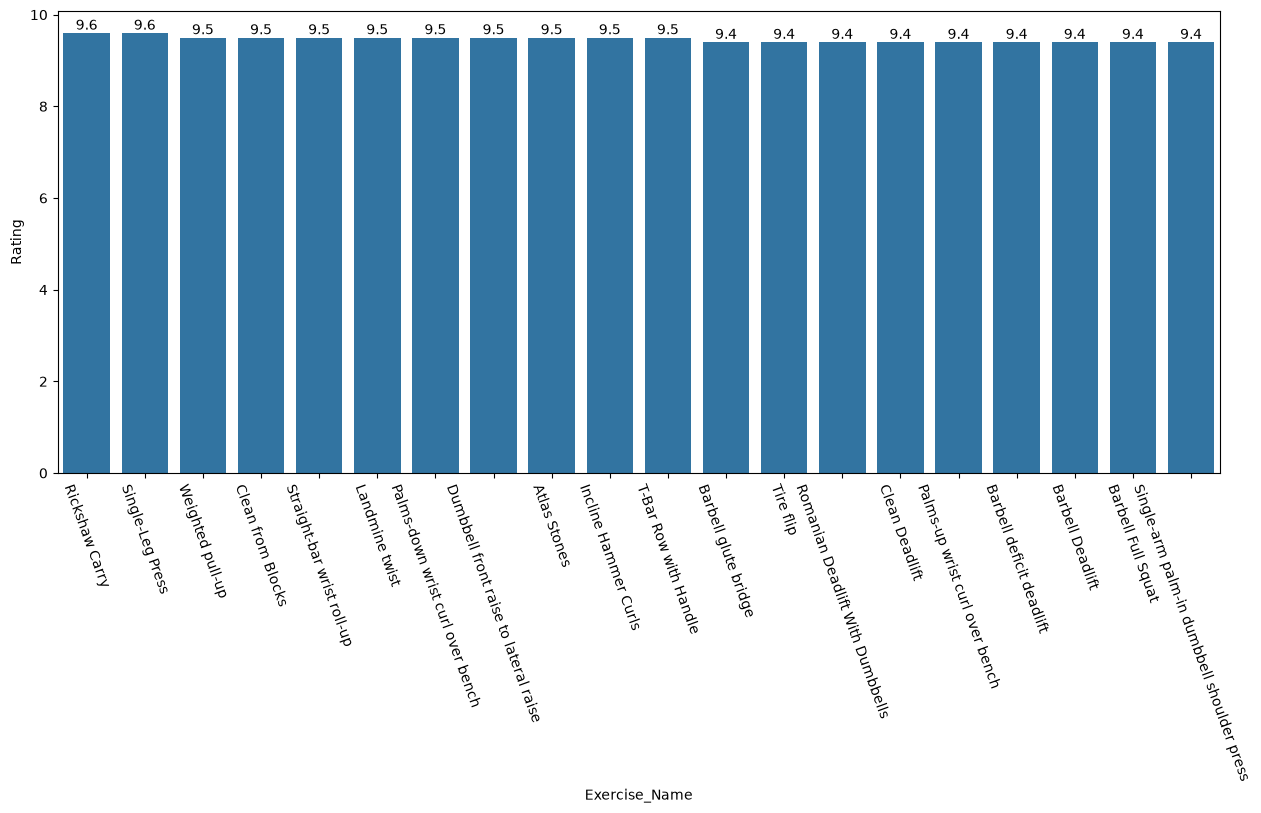

In [40]:
# Top 10 highest rated exericses
plt.figure(figsize=(15, 6))
plt.xticks(rotation=290)
rating_sorted_data = data.sort_values(by="Rating", ascending=False).head(20)
ax = sns.barplot(data=rating_sorted_data, x=rating_sorted_data.Exercise_Name, y=rating_sorted_data.Rating)
ax.bar_label(ax.containers[0], fontsize=10)
plt.show()

In [41]:
# Cosine similarity matrix to find the best alternatives for exercises provided
from workout_intel_core.features import (
    exercise_feature_matrix,
    compute_similarity_matrix,
    recommend_exercise
)

matrix = exercise_feature_matrix()
similarity_df = compute_similarity_matrix(matrix)

recs = recommend_exercise("Triceps dip", similarity_df, top_n=5)
print(recs)

Exercise_Name
Ring dip                             1.0
Parallel Bar Dip                     1.0
Feet-elevated bench dip              1.0
Push-Ups - Close Triceps Position    1.0
Name: Triceps dip, dtype: float64
